In [31]:
import seaborn as sns
import numpy as np
import functools as ft
import matplotlib.pyplot as plt

In [ ]:
tpu_flops = 1.97e14
tpu_bw = 8.2e11

def roofline(d, f, b):
    alg_flops= 2 * b * d * f
    alg_comms = 2 * b * d + d * f + 2 * b * f
    computation_t = alg_flops / tpu_flops
    comm_t = alg_comms / tpu_bw
    
    return computation_t / np.maximum(computation_t, comm_t)

f1= ft.partial(roofline, 4096, 4096)
f2 = ft.partial(roofline, 1024, 1024)

In [33]:
n = 512
x1 = f1(np.arange(1, n+1))
x2 = f2(np.arange(1, n+1))

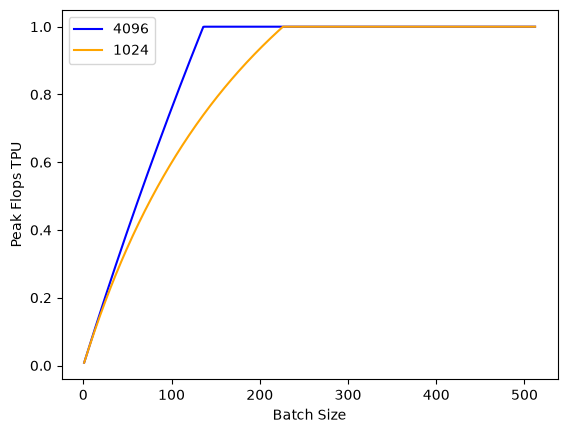

In [ ]:
batch_sizes = np.arange(1, n+1)

fig, ax = plt.subplots()
sns.lineplot(x=batch_sizes, y=x1, ax=ax, label="4096", color="blue")
sns.lineplot(x=batch_sizes, y=x2, ax=ax, label="1024", color="orange")
ax.set_xlabel("Batch Size")
ax.set_ylabel("Peak Flops TPU")
ax.legend()
plt.show()